# Tugas

# IMPORT LIBRARY

In [1]:
# =========================
# IMPORT LIBRARY
# =========================

# Manipulasi data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Split Data
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Evaluasi Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Simpan Model
import joblib

In [2]:
# =========================
# LOAD DATASET
# =========================

df = pd.read_excel("dataset_kelulusan_raw.xlsx")

# Menampilkan 5 data pertama
df.head()

,Tahun_Masuk,IPS_S1,IPS_S2,IPS_S3,IPS_S4,IPK,MK_Gagal,SKS_Lulus,Status_Skripsi,Jumlah_Bimbingan,Ontime
0,2018,2.67,2.57,2.71,2.58,2.63,4,127,Belum,4,Tidak Ontime
1,2021,3.56,3.68,3.85,3.94,3.76,0,143,Semhas,13,Ontime
2,2022,3.17,3.18,3.30,3.40,3.26,0,148,Semhas,18,Ontime
3,2019,2.04,2.00,2.03,2.00,2.02,4,127,Judul ACC,2,Tidak Ontime
4,2020,3.69,3.58,3.52,3.42,3.55,2,146,Semhas,14,Ontime


STRUKTUR DATASET

In [3]:
# =========================
# INFORMASI DATASET
# =========================

print(df.info())

# Jumlah baris dan kolom
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tahun_Masuk       200 non-null    int64  
 1   IPS_S1            200 non-null    float64
 2   IPS_S2            200 non-null    float64
 3   IPS_S3            200 non-null    float64
 4   IPS_S4            200 non-null    float64
 5   IPK               200 non-null    float64
 6   MK_Gagal          200 non-null    int64  
 7   SKS_Lulus         200 non-null    int64  
 8   Status_Skripsi    200 non-null    object 
 9   Jumlah_Bimbingan  200 non-null    int64  
 10  Ontime            200 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 17.3+ KB
None
(200, 11)


DISTRIBUSI TARGET

Ontime
Ontime          130
Tidak Ontime     70
Name: count, dtype: int64


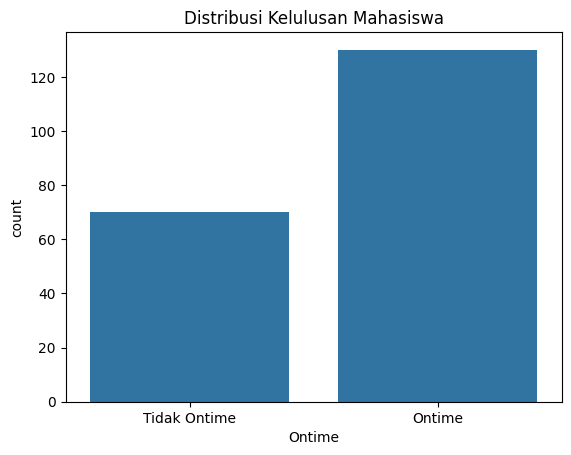

In [4]:
# Distribusi label target
print(df['Ontime'].value_counts())

sns.countplot(
    data=df,
    x='Ontime'
)

plt.title("Distribusi Kelulusan Mahasiswa")

plt.show()

# DATA PREPARATION

DATA CLEANING

In [ ]:
# =========================
# CEK MISSING VALUE
# =========================

print(df.isnull().sum())

# =========================
# HAPUS MISSING VALUE
# =========================

df = df.dropna()

# =========================
# CEK DATA DUPLIKAT
# =========================

print("Jumlah Data Duplikat:")
print(df.duplicated().sum())

# =========================
# HAPUS DATA DUPLIKAT
# =========================

df = df.drop_duplicates()

# =========================
# MEMBERSIHKAN STATUS SKRIPSI
# =========================

df['Status_Skripsi'] = (
    df['Status_Skripsi']
    .astype(str)
    .str.strip()
    .str.title()
)

# =========================
# MEMBERSIHKAN TARGET
# =========================

df['Ontime'] = (
    df['Ontime']
    .astype(str)
    .str.strip()
    .str.title()
)

Tahun_Masuk         0
IPS_S1              0
IPS_S2              0
IPS_S3              0
IPS_S4              0
IPK                 0
MK_Gagal            0
SKS_Lulus           0
Status_Skripsi      0
Jumlah_Bimbingan    0
Ontime              0
dtype: int64
Jumlah Data Duplikat:
0


DATA TRANSFORMATION

In [6]:
# =========================
# ENCODING STATUS SKRIPSI
# =========================

status_mapping = {
    'Belum': 0,
    'Judul Acc': 1,
    'Sempro': 2,
    'Semhas': 3,
    'Skripsi': 4
}

df['Status_Skripsi'] = df['Status_Skripsi'].map(status_mapping)

df.head()

,Tahun_Masuk,IPS_S1,IPS_S2,IPS_S3,IPS_S4,IPK,MK_Gagal,SKS_Lulus,Status_Skripsi,Jumlah_Bimbingan,Ontime
0,2018,2.67,2.57,2.71,2.58,2.63,4,127,0,4,Tidak Ontime
1,2021,3.56,3.68,3.85,3.94,3.76,0,143,3,13,Ontime
2,2022,3.17,3.18,3.30,3.40,3.26,0,148,3,18,Ontime
3,2019,2.04,2.00,2.03,2.00,2.02,4,127,1,2,Tidak Ontime
4,2020,3.69,3.58,3.52,3.42,3.55,2,146,3,14,Ontime


In [7]:
# =========================
# ENCODING TARGET
# =========================

target_mapping = {
    'Ontime': 1,
    'Tidak Ontime': 0
}

df['Ontime'] = df['Ontime'].map(target_mapping)

df.head()

,Tahun_Masuk,IPS_S1,IPS_S2,IPS_S3,IPS_S4,IPK,MK_Gagal,SKS_Lulus,Status_Skripsi,Jumlah_Bimbingan,Ontime
0,2018,2.67,2.57,2.71,2.58,2.63,4,127,0,4,0
1,2021,3.56,3.68,3.85,3.94,3.76,0,143,3,13,1
2,2022,3.17,3.18,3.30,3.40,3.26,0,148,3,18,1
3,2019,2.04,2.00,2.03,2.00,2.02,4,127,1,2,0
4,2020,3.69,3.58,3.52,3.42,3.55,2,146,3,14,1


In [8]:
# =========================
# SIMPAN DATASET HASIL ENCODING
# =========================

df.to_excel(
    "dataset_kelulusan_encoded.xlsx",
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


FEATURE ENGINEERING

In [9]:
# =========================
# FITUR RATA-RATA IP
# =========================

df['Rata_Rata_IP'] = (
    df['IPS_S1'] +
    df['IPS_S2'] +
    df['IPS_S3'] +
    df['IPS_S4']
) / 4

In [10]:
# =========================
# FITUR PROGRESS SKS
# =========================

df['Progress_SKS'] = (
    df['SKS_Lulus'] / 144
)

In [11]:
# =========================
# FITUR TREN IP
# =========================

df['Tren_IP'] = (
    df['IPS_S4'] -
    df['IPS_S1']
)

In [12]:
# =========================
# HASIL FEATURE ENGINEERING
# =========================

df.head()

,Tahun_Masuk,IPS_S1,IPS_S2,IPS_S3,IPS_S4,IPK,MK_Gagal,SKS_Lulus,Status_Skripsi,Jumlah_Bimbingan,Ontime,Rata_Rata_IP,Progress_SKS,Tren_IP
0,2018,2.67,2.57,2.71,2.58,2.63,4,127,0,4,0,2.6325,0.881944,-0.09
1,2021,3.56,3.68,3.85,3.94,3.76,0,143,3,13,1,3.7575,0.993056,0.38
2,2022,3.17,3.18,3.30,3.40,3.26,0,148,3,18,1,3.2625,1.027778,0.23
3,2019,2.04,2.00,2.03,2.00,2.02,4,127,1,2,0,2.0175,0.881944,-0.04
4,2020,3.69,3.58,3.52,3.42,3.55,2,146,3,14,1,3.5525,1.013889,-0.27


In [13]:
# =========================
# SIMPAN DATASET FINAL
# =========================

df.to_excel(
    "dataset_kelulusan_final.xlsx",
    index=False
)

print("Dataset final berhasil disimpan")

Dataset final berhasil disimpan


FEATURE SELECTION

In [14]:
# =========================
# FEATURE DAN TARGET
# =========================

X = df.drop('Ontime', axis=1)

y = df['Ontime']

In [15]:
# =========================
# DAFTAR FEATURE
# =========================

print(X.columns)

Index(['Tahun_Masuk', 'IPS_S1', 'IPS_S2', 'IPS_S3', 'IPS_S4', 'IPK',
       'MK_Gagal', 'SKS_Lulus', 'Status_Skripsi', 'Jumlah_Bimbingan',
       'Rata_Rata_IP', 'Progress_SKS', 'Tren_IP'],
      dtype='object')


# MODELING

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
# =========================
# SPLIT DATA
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Melihat jumlah data
print("Jumlah Data Training :", len(X_train))
print("Jumlah Data Testing  :", len(X_test))

Jumlah Data Training : 160
Jumlah Data Testing  : 40


In [18]:
# =========================
# DATA TRAINING
# =========================

train_data = X_train.copy()

train_data['Ontime'] = y_train

# Simpan ke Excel
train_data.to_excel(
    "data_training.xlsx",
    index=False
)

print("Data training berhasil disimpan")

Data training berhasil disimpan


In [19]:
# =========================
# DATA TESTING
# =========================

test_data = X_test.copy()

test_data['Ontime'] = y_test

# Simpan ke Excel
test_data.to_excel(
    "data_testing.xlsx",
    index=False
)

print("Data testing berhasil disimpan")

Data testing berhasil disimpan


In [20]:
# =========================
# MEMBUAT MODEL RANDOM FOREST
# =========================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# =========================
# TRAINING MODEL
# =========================

model.fit(X_train, y_train)

print("Model berhasil dilatih")

Model berhasil dilatih


In [21]:
# =========================
# PREDIKSI DATA TESTING
# =========================

y_pred = model.predict(X_test)

# Menampilkan hasil prediksi
print(y_pred)

[1 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 1 0
 0 1 0]


In [22]:
# =========================
# HASIL PREDIKSI
# =========================

hasil_prediksi = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_pred
})

print(hasil_prediksi.head(10))

     Aktual  Prediksi
95        1         1
15        0         0
30        1         1
158       1         1
128       1         1
115       0         0
69        0         0
170       1         1
174       1         1
45        0         0


In [23]:
# =========================
# SIMPAN HASIL PREDIKSI
# =========================

hasil_prediksi.to_excel(
    "hasil_prediksi_testing.xlsx",
    index=False
)

print("Hasil prediksi berhasil disimpan")

Hasil prediksi berhasil disimpan


In [24]:
# =========================
# DATA MAHASISWA BARU
# =========================

data_baru = [[
    2021,   # Tahun_Masuk
    3.40,   # IPS_S1
    3.50,   # IPS_S2
    3.45,   # IPS_S3
    3.60,   # IPS_S4
    3.49,   # IPK
    1,      # MK_Gagal
    145,    # SKS_Lulus
    4,      # Status_Skripsi (Skripsi)
    15,     # Jumlah_Bimbingan
    3.49,   # Rata_Rata_IP
    1.00,   # Progress_SKS
    0.20    # Tren_IP
]]

In [25]:
# =========================
# PREDIKSI DATA BARU
# =========================

prediksi_baru = model.predict(data_baru)

print("Hasil Prediksi:", prediksi_baru)

Hasil Prediksi: [1]


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [26]:
# =========================
# INTERPRETASI HASIL
# =========================

if prediksi_baru[0] == 1:

    print("Mahasiswa diprediksi Lulus Tepat Waktu")

else:

    print("Mahasiswa diprediksi Tidak Lulus Tepat Waktu")

Mahasiswa diprediksi Lulus Tepat Waktu


# EVALUATION

In [27]:
# =========================
# ACCURACY
# =========================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 1.0


In [28]:
# =========================
# PRECISION
# =========================

precision = precision_score(
    y_test,
    y_pred
)

print("Precision :", precision)

Precision : 1.0


In [29]:
# =========================
# RECALL
# =========================

recall = recall_score(
    y_test,
    y_pred
)

print("Recall :", recall)

Recall : 1.0


[[20  0]
 [ 0 20]]


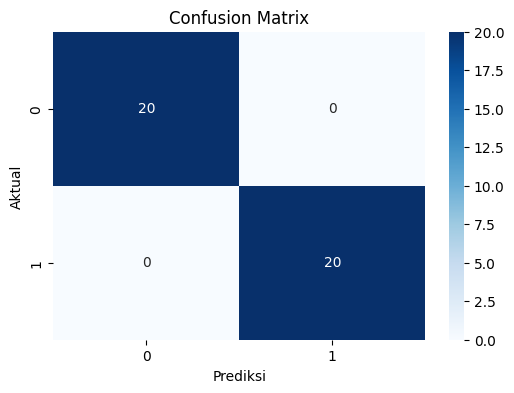

In [30]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

# =========================
# VISUALISASI CONFUSION MATRIX
# =========================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

In [31]:
# =========================
# CLASSIFICATION REPORT
# =========================

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [32]:
# =========================
# FEATURE IMPORTANCE
# =========================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Feature  Importance
6           MK_Gagal    0.268291
7          SKS_Lulus    0.207151
9   Jumlah_Bimbingan    0.177915
11      Progress_SKS    0.128014
10      Rata_Rata_IP    0.060875
4             IPS_S4    0.048620
1             IPS_S1    0.032008
2             IPS_S2    0.023765
3             IPS_S3    0.022463
5                IPK    0.014984
8     Status_Skripsi    0.014327
0        Tahun_Masuk    0.001589
12           Tren_IP    0.000000


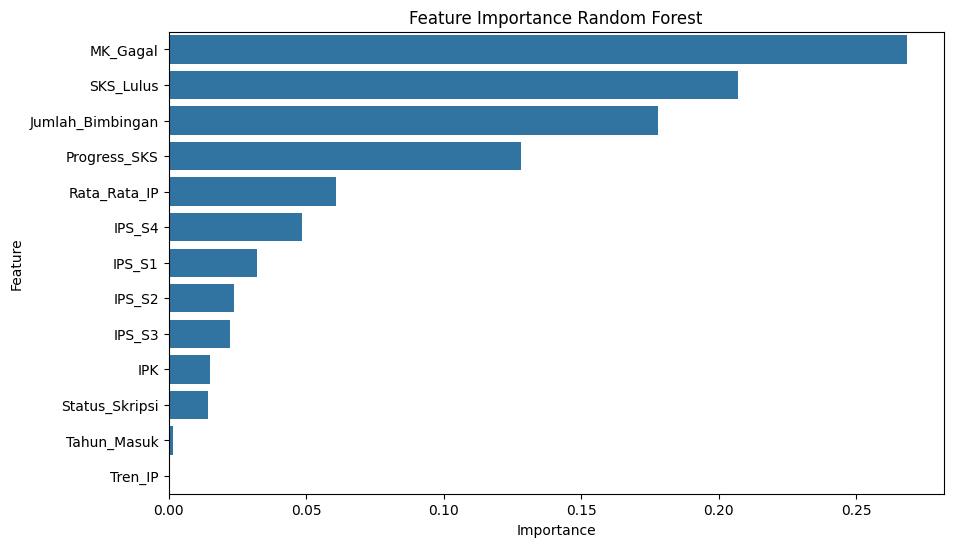

In [33]:
# =========================
# VISUALISASI FEATURE IMPORTANCE
# =========================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance Random Forest")

plt.show()

# DEPLOYMENT

In [34]:
joblib.dump(model, 'model_kelulusan.pkl')

['model_kelulusan.pkl']